In [1]:
import yfinance as yf

In [2]:
!pip3 install numpy

In [3]:
import numpy as np

In [4]:
import sys

In [5]:
sp500 = yf.Ticker("^GSPC")

In [6]:
sp500 = sp500.history(period="max")

In [7]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2025-07-23 00:00:00-04:00', '2025-07-24 00:00:00-04:00',
               '2025-07-25 00:00:00-04:00', '2025-07-28 00:00:00-04:00',
               '2025-07-29 00:00:00-04:00', '2025-07-30 00:00:00-04:00',
               '2025-07-31 00:00:00-04:00', '2025-08-01 00:00:00-04:00',
               '2025-08-04 00:00:00-04:00', '2025-08-05 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24514, freq=None)

<Axes: xlabel='Date'>

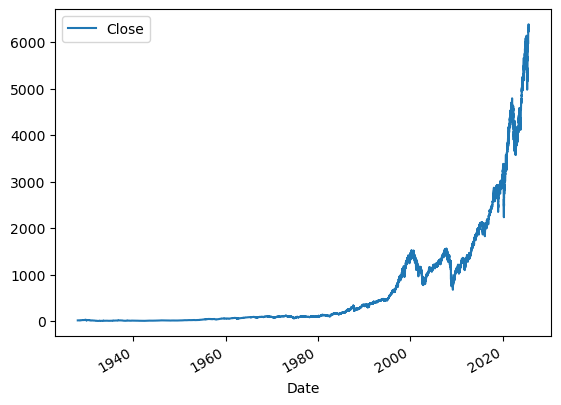

In [8]:
sp500.plot.line(y="Close", use_index=True)

In [9]:
del sp500["Dividends"]

In [10]:
del sp500["Stock Splits"]

In [11]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [12]:
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)
#target is "1" if tomorrow's price increased and "0" if it decreased

In [13]:
#removes all rows before Jan 1, 1990
sp500 = sp500.loc["1985-01-01":].copy()

In [14]:
!pip install --upgrade --force-reinstall numpy scipy scikit-learn

  Using cached numpy-2.3.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached scipy-1.16.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (61 kB)
  Using cached scikit_learn-1.7.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached numpy-2.3.2-cp312-cp312-macosx_14_0_arm64.whl (5.1 MB)
Using cached scipy-1.16.1-cp312-cp312-macosx_14_0_arm64.whl (20.9 MB)
Using cached scikit_learn-1.7.1-cp312-cp312-macosx_12_0_arm64.whl (8.6 MB)
Using cached joblib-1.5.1-py3-none-any.whl (307 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfully uninstalled threadpoolctl-3.6.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.2
    Uninstalling numpy-2.3.2:
      Successfully

In [15]:
import sklearn

In [16]:
from sklearn.ensemble import RandomForestClassifier
#Random forest are more resistent to overfitting

# Incerased n_esitmators improves accuracy up to a cetain point. 
# min_samples_split helps stop overfitting but decreases accuracy
model = RandomForestClassifier(n_estimators=200, min_samples_split=100, random_state=1)

train = sp500.iloc[:-100] #all the rows except the last 100
test = sp500.iloc[-100:] #only the last 100 rows

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
RandomForestClassifier(min_samples_split=100, random_state=1)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
from sklearn.metrics import precision_score
# How accurate was the model when predicting "Target" if it will go up (percent)

preds = model.predict(test[predictors])

In [19]:
import pandas as pd

In [20]:
preds = pd.Series(preds, index=test.index)

In [21]:
precision_score(test["Target"], preds)

0.6

In [22]:
combined = pd.concat([test["Target"], preds], axis=1)

<Axes: xlabel='Date'>

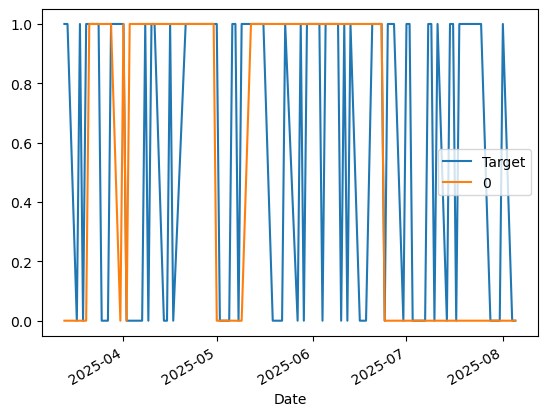

In [23]:
combined.plot()

In [24]:

def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"]) #fit model using training and target
    preds = model.predict(test[predictors]) #generates predictions
    preds = pd.Series(preds, index=test.index, name = "Predictions") #puts model into a series
    combined = pd.concat([test["Target"], preds], axis=1) #combines everything together
    return combined

In [25]:
def backtest(data, model, predictors, start=3000, step=250): #start=2500 means train the first model with 10 years of data
    all_predictions = []
    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [26]:
#predictions = backtest(sp500, model, predictors)

In [27]:
#predictions["Predictions"].value_counts()

In [28]:
#precision_score(predictions["Target"], predictions["Predictions"])

In [29]:
#predictions["Target"].value_counts() / predictions.shape[0] #this is the actual percentange of if it went up or down


In [30]:
horizons = [2,5,60,250,1000] #calc mean close price in the last 2 days, 5 days, 3 months, etc...
new_predictors = []

for horizon in horizons:
    rolling_average = sp500.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    sp500[ratio_column] = sp500 ["Close"] / rolling_average["Close"]

    trend_column =f"Trend_{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]

    new_predictors += [ratio_column, trend_column]

In [31]:
sp500 = sp500.dropna()

In [32]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1988-12-15 00:00:00-05:00,275.320007,275.619995,274.010010,274.279999,136820000,276.290009,1,0.998126,0.0,0.994164,1.0,1.001176,32.0,1.035299,136.0,1.124908,553.0
1988-12-16 00:00:00-05:00,274.279999,276.290009,274.279999,276.290009,196480000,278.910004,1,1.003651,1.0,1.001987,1.0,1.008077,33.0,1.042471,136.0,1.132632,554.0
1988-12-19 00:00:00-05:00,276.290009,279.309998,275.609985,278.910004,162250000,277.470001,0,1.004719,2.0,1.009739,2.0,1.017070,33.0,1.051948,136.0,1.142833,555.0
1988-12-20 00:00:00-05:00,278.910004,280.450012,277.470001,277.470001,161090000,277.380005,0,0.997412,1.0,1.003682,2.0,1.011291,33.0,1.046115,136.0,1.136405,554.0
1988-12-21 00:00:00-05:00,277.470001,277.829987,276.299988,277.380005,147250000,276.869995,0,0.999838,0.0,1.001856,2.0,1.010403,33.0,1.045274,136.0,1.135509,554.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-29 00:00:00-04:00,6405.620117,6409.259766,6363.919922,6370.859863,5076120000,6362.899902,0,0.998518,1.0,0.999459,4.0,1.053485,37.0,1.093257,144.0,1.332944,532.0
2025-07-30 00:00:00-04:00,6381.229980,6396.540039,6336.379883,6362.899902,5375070000,6339.390137,0,0.999375,0.0,0.998086,3.0,1.050211,36.0,1.091197,144.0,1.330733,532.0
2025-07-31 00:00:00-04:00,6427.020020,6427.020020,6327.640137,6339.390137,6077080000,6238.009766,0,0.998149,0.0,0.995146,2.0,1.044352,36.0,1.086557,143.0,1.325286,531.0


In [33]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [34]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"]) #fit model using training and target
    preds = model.predict_proba(test[predictors])[:,1] #gives the probability of the stock going up
    preds[preds >= .6] = 1
    preds[preds < .6] = 0
    preds = pd.Series(preds, index=test.index, name = "Predictions") #puts model into a series
    combined = pd.concat([test["Target"], preds], axis=1) #combines everything together
    return combined

In [35]:
#predictions = backtest(sp500, model, new_predictors)

In [36]:
#predictions["Predictions"].value_counts()

In [37]:
#precision_score(predictions["Target"], predictions["Predictions"])

In [38]:
#now I want to train the model on CPI, PPI, Unemployment, GDP, and the fed interest rates.

In [39]:
!pip install fredapi

In [40]:
%pip install --upgrade --force-reinstall numpy pandas

  Using cached numpy-2.3.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached pandas-2.3.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-2.3.2-cp312-cp312-macosx_14_0_arm64.whl (5.1 MB)
Using cached pandas-2.3.1-cp312-cp312-macosx_11_0_arm64.whl (10.7 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Found e

In [41]:
from fredapi import Fred

In [42]:
fred = Fred(api_key='1589088aac5d668a6d59c92eb458255e')

In [43]:
cpi = fred.get_series('CPIAUCSL')           # Consumer Price Index
ppi = fred.get_series('PPIACO')             # Producer Price Index
unemployment = fred.get_series('UNRATE')    # Unemployment rate
gdp = fred.get_series('A191RL1Q225SBEA')     # Real GDP Growth (percent change)
interest_rate = fred.get_series('FEDFUNDS') # Federal Funds Rate

In [44]:
#cutting off all dates before 1993-12-01
#cpi = cpi.loc["1993-12-01":].copy()
#ppi = ppi.loc["1993-12-01":].copy()
#unemployment = unemployment.loc["1993-12-01":].copy()
#gdp = gdp.loc["1993-12-01":].copy()
#interest_rate = interest_rate.loc["1993-12-01":].copy()

In [45]:
cpi = cpi.rename('CPI')
ppi = ppi.rename('PPI')
gdp = gdp.rename('GDP')
unemployment = unemployment.rename('Unemployment')
interest_rate = interest_rate.rename('InterestRate')

In [46]:
cpi = cpi.resample('D').ffill()  # Forward-fill cpi data to each day
ppi = ppi.resample('D').ffill()  # Forward-fill ppi data to each day
unemployment = unemployment.resample('D').ffill()  # Forward-fill unemployment data to each day
interest_rate = interest_rate.resample('D').ffill()  # Forward-fill interest rate data to each day
gdp = gdp.resample('D').ffill()  # Forward-fill macro data to each day

In [47]:
cpi.index

DatetimeIndex(['1947-01-01', '1947-01-02', '1947-01-03', '1947-01-04',
               '1947-01-05', '1947-01-06', '1947-01-07', '1947-01-08',
               '1947-01-09', '1947-01-10',
               ...
               '2025-05-23', '2025-05-24', '2025-05-25', '2025-05-26',
               '2025-05-27', '2025-05-28', '2025-05-29', '2025-05-30',
               '2025-05-31', '2025-06-01'],
              dtype='datetime64[ns]', length=28642, freq='D')

In [48]:
sp500.index = sp500.index.tz_localize(None)

In [49]:
sp500.index

DatetimeIndex(['1988-12-15', '1988-12-16', '1988-12-19', '1988-12-20',
               '1988-12-21', '1988-12-22', '1988-12-23', '1988-12-27',
               '1988-12-28', '1988-12-29',
               ...
               '2025-07-22', '2025-07-23', '2025-07-24', '2025-07-25',
               '2025-07-28', '2025-07-29', '2025-07-30', '2025-07-31',
               '2025-08-01', '2025-08-04'],
              dtype='datetime64[ns]', name='Date', length=9226, freq=None)

In [50]:
sp500 = sp500.join([cpi, ppi, gdp, unemployment, interest_rate], how='left')

In [51]:
#adds data for the specified dates so GDP data begins and ends at the same time as all the other data.
sp500.loc['2025-01-02':'2025-03-31', 'GDP'] = -0.5
sp500.loc['2025-04-01':'2025-06-30', 'GDP'] = 3
sp500.loc['2025-06-01':'2025-06-30', 'CPI'] = 321.50
sp500.loc['2025-06-01':'2025-06-30', 'PPI'] = 260.180
sp500.loc['2025-07-01':'2025-07-31', 'Unemployment'] = 4.2
sp500.loc['2025-07-01':'2025-07-31', 'InterestRate'] = 4.33

In [52]:
sp500 = sp500.copy()

In [85]:
for col in ['CPI', 'PPI', 'GDP', 'Unemployment', 'InterestRate']:
    sp500.loc[:, col + '_Lag1'] = sp500[col].shift(1)

In [95]:
horizons = [2,5,60,250,1000]
predictors3 = ["CPI", "GDP", "InterestRate"]

for horizon in horizons:
    rolling_average = sp500.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    sp500.loc[:, ratio_column] = sp500["Close"] / rolling_average["Close"]

    trend_column = f"Trend_{horizon}"
    sp500.loc[:, trend_column] = sp500["Target"].shift(1).rolling(horizon).sum()

    predictors3 += [ratio_column, trend_column]


In [87]:
sp500 = sp500.dropna()

In [90]:
model3 = RandomForestClassifier(n_estimators=180, min_samples_split=75, random_state=1)

train = sp500.iloc[:-100] #all the rows except the last 100
test = sp500.iloc[-100:] #only the last 100 rows

model3.fit(train[predictors3], train["Target"])

,n_estimators,180
,criterion,'gini'
,max_depth,None
,min_samples_split,75
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [91]:
predictions = backtest(sp500, model3, predictors3)

In [92]:
predictions["Predictions"].value_counts()

Predictions
0.0    3683
1.0     519
Name: count, dtype: int64

In [93]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5337186897880539

In [94]:
predictors3

['CPI_Lag1',
 'GDP_Lag1',
 'InterestRate_Lag1',
 'Close_Ratio_2',
 'Trend_2',
 'Close_Ratio_5',
 'Trend_5',
 'Close_Ratio_60',
 'Trend_60',
 'Close_Ratio_250',
 'Trend_250',
 'Close_Ratio_1000',
 'Trend_1000']

In [89]:
#none: 54.72%
#cpi_mom: 54.11%
#ppi_mom: 55.36%
#gdp_mom: 54.02%
#unemployment_mom: 56.45%
#interestrate_mom: 53.34%

#cpi,gdp,IR: 57.87%

In [86]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,...,CPI_MoM,PPI_MoM,GDP_MoM,Unemployment_MoM,InterestRate_MoM,CPI_Lag1,PPI_Lag1,GDP_Lag1,Unemployment_Lag1,InterestRate_Lag1
Date,,,,,,,,,,,,,,,,,,,,,
1992-11-30,430.190002,431.529999,429.359985,431.350006,2.301500e+08,430.779999,0.0,NaN,NaN,NaN,...,0.002823,-0.002540,0.0,0.013699,-0.003226,NaN,NaN,NaN,NaN,NaN
1992-12-01,431.350006,431.470001,429.200012,430.779999,2.590500e+08,429.890015,0.0,0.999339,NaN,NaN,...,0.004234,-0.004234,0.0,0.013699,-0.058065,142.1,117.80,4.2,7.4,3.09
1992-12-02,430.779999,430.869995,428.609985,429.890015,2.470100e+08,429.910004,1.0,0.998966,0.0,NaN,...,0.004234,-0.004234,0.0,0.013699,-0.058065,142.3,117.60,4.2,7.4,2.92
1992-12-03,429.980011,430.989990,428.799988,429.910004,2.380500e+08,432.059998,1.0,1.000023,1.0,NaN,...,0.004234,-0.004234,0.0,0.013699,-0.058065,142.3,117.60,4.2,7.4,2.92
1992-12-04,429.929993,432.890015,429.739990,432.059998,2.349600e+08,435.309998,1.0,1.002494,2.0,1.002929,...,0.004234,-0.004234,0.0,0.013699,-0.058065,142.3,117.60,4.2,7.4,2.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-24,6061.209961,6101.759766,6059.250000,6092.180176,5.443690e+09,6092.160156,0.0,1.005530,2.0,1.013715,...,0.002870,0.006495,0.0,-0.023810,0.000000,321.5,260.18,3.0,4.1,4.33
2025-06-25,6104.229980,6108.509766,6080.089844,6092.160156,5.171110e+09,6141.020020,1.0,0.999998,1.0,1.010033,...,0.002870,0.006495,0.0,-0.023810,0.000000,321.5,260.18,3.0,4.1,4.33
2025-06-26,6112.089844,6146.520020,6107.270020,6141.020020,5.308140e+09,6173.069824,1.0,1.003994,1.0,1.012756,...,0.002870,0.006495,0.0,-0.023810,0.000000,321.5,260.18,3.0,4.1,4.33
